# **📊 Telecom X – Análisis de Cancelación de Clientes**

## Introducción
####La cancelación de clientes, conocida como *churn*, es un problema importante en las empresas de telecomunicaciones. Comprender por qué los clientes abandonan el servicio permite a las empresas desarrollar estrategias para mejorar la retención.

####En este proyecto se analiza un conjunto de datos de clientes de Telecom X con el objetivo de identificar patrones asociados a la cancelación y construir un modelo de machine learning capaz de predecir qué clientes tienen mayor probabilidad de abandonar el servicio.

## Objetivos

####- Analizar los datos de clientes
####- Realizar limpieza y preparación del dataset
####- Identificar variables relacionadas con el churn
####- Construir un modelo de predicción utilizando regresión logística
####- Evaluar el desempeño del modelo

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del dataset

####En esta sección se cargan los datos que contienen información sobre los clientes de Telecom X y sus características de servicio.

In [38]:
df = pd.read_csv("datos_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


## Exploración inicial de los datos

####Se analiza la estructura del dataset para conocer el tipo de variables y detectar posibles valores faltantes.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [40]:
df.shape

(7267, 22)

## Limpieza y preparación de datos

####En esta etapa se eliminan columnas innecesarias, se corrigen tipos de datos y se eliminan valores faltantes.

In [41]:
df = df.drop("customerID", axis=1)

In [42]:
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")

In [43]:
df = df.dropna(subset=["Churn"])
df = df.dropna(subset=["Charges.Total"])

## Transformación de variables

####Las variables categóricas deben transformarse en variables numéricas para poder ser utilizadas por los modelos de machine learning.

In [44]:
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [45]:
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

## Análisis exploratorio

####Se analiza la correlación entre las variables para identificar cuáles están más relacionadas con la cancelación de clientes.

In [46]:
corr = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

corr.head(10)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Cuentas_Diarias,0.192858
Charges.Monthly,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033


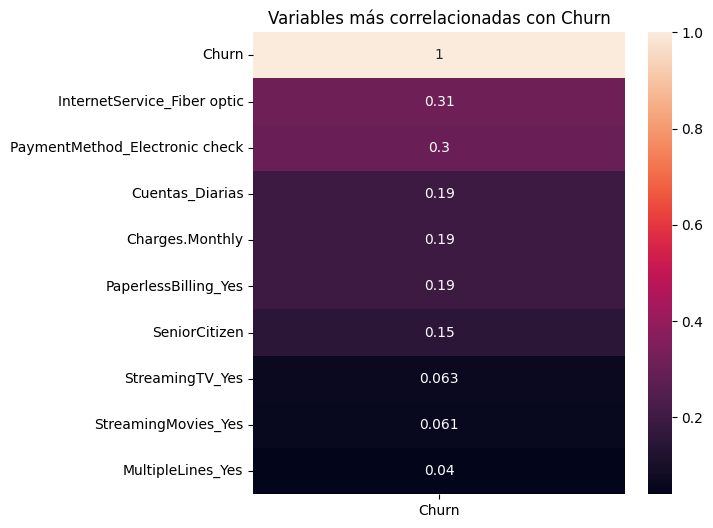

In [47]:
plt.figure(figsize=(6,6))
sns.heatmap(corr.head(10).to_frame(), annot=True)
plt.title("Variables más correlacionadas con Churn")
plt.show()

## Preparación de los datos

####Se separan las variables predictoras y la variable objetivo, y luego se dividen los datos en conjuntos de entrenamiento y prueba.

In [48]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento del modelo

####Se utiliza un modelo de regresión logística para predecir la probabilidad de cancelación de los clientes.

In [51]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [52]:
y_pred = modelo_lr.predict(X_test_scaled)

## Evaluación del modelo

####Se evalúa el desempeño del modelo utilizando métricas de clasificación y una matriz de confusión.

In [53]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



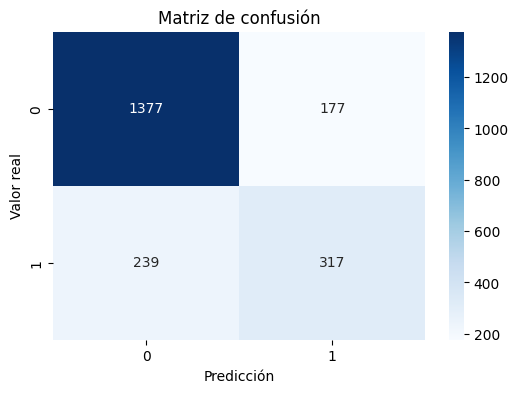

In [54]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

plt.show()

# Conclusión


####A partir del análisis de los datos se identificaron algunas variables que influyen en la cancelación de clientes, como el tipo de servicio de internet, el método de pago y los cargos mensuales.

####El modelo de regresión logística obtuvo aproximadamente un 80% de precisión, mostrando una buena capacidad para identificar clientes que permanecen en el servicio y una capacidad moderada para detectar clientes que cancelan.

####Estos resultados permiten comprender mejor los factores asociados al churn y pueden servir como base para desarrollar estrategias de retención de clientes.